# Exp B-2 — Synthetic CV_MI Control Study

**Goal:** Establish statistical support for the claim that CV(μ) predicts AISO success.

With only 3 real datasets Spearman r=-1.0 is trivially uninterpretable.
Here we generate 45 synthetic datasets (15 CV_MI levels × 3 seeds) and correlate
measured CV_MI with AISO Delta PR-AUC vs random baseline.

**Design:**
- D=48 features, K=8 clusters (6 features each), N=2000 samples
- CV_MI controlled via cluster weight concentration parameter c
- AISO wrapper (fast settings) vs random feature selection
- Metric: Delta PR-AUC = AISO - random

**Kernel:** .venv

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import average_precision_score, roc_auc_score

# Experiment parameters
K       = 8     # feature clusters
F_PER_K = 6     # features per cluster
D       = K * F_PER_K
N       = 2000
K_SEL   = 12    # features to select
SEEDS   = [0, 42, 99]

# CV_MI concentration levels: c=0 → uniform MI, c=4 → one cluster dominates
C_LEVELS = np.linspace(0.0, 4.0, 15)

print(f'D={D}, N={N}, K_SEL={K_SEL}')
print(f'Runs: {len(C_LEVELS)} levels × {len(SEEDS)} seeds = {len(C_LEVELS)*len(SEEDS)} total')

D=48, N=2000, K_SEL=12
Runs: 15 levels × 3 seeds = 45 total


In [2]:
def make_dataset(c, seed=42):
    """Generate synthetic dataset with controlled MI concentration.
    
    c=0: all clusters equally relevant (low CV_MI)
    c=4: first cluster dominates (high CV_MI)
    """
    rng = np.random.RandomState(seed)
    
    # Cluster weights: softmax([c, 0, 0, ...])
    logits = np.zeros(K); logits[0] = c
    w = np.exp(logits); w /= w.sum()
    
    # Latent cluster signals
    Z = rng.randn(N, K)  # (N, K)
    
    # Features: each cluster k has F_PER_K features = 0.85*z_k + noise
    X = np.zeros((N, D))
    for k in range(K):
        cols = slice(k*F_PER_K, (k+1)*F_PER_K)
        X[:, cols] = 0.85 * Z[:, k:k+1] + 0.15 * rng.randn(N, F_PER_K)
    
    # Label: weighted sum of cluster signals, threshold at median
    signal = Z @ w + 0.3 * rng.randn(N)
    y = (signal > np.median(signal)).astype(int)
    
    return X, y, w


def measure_cv_mi(X, y, seed=42):
    """Compute actual CV_MI from data using same method as Exp B."""
    MI = mutual_info_classif(X, y, random_state=seed)
    # True cluster labels (known in synthetic case)
    labels = np.repeat(np.arange(K), F_PER_K)
    mu_c = np.array([MI[labels == k].mean() for k in range(K)])
    cv = mu_c.std() / (mu_c.mean() + 1e-8)
    return cv, MI, labels


print('Dataset generator ready')

Dataset generator ready


In [3]:
def build_smart_M(MI, labels, C_abs, gamma=0.5):
    mean_MI = np.array([MI[labels == k].mean() if (labels == k).any() else 0.0 for k in range(K)])
    MI_norm = (mean_MI - mean_MI.min()) / (mean_MI.max() - mean_MI.min() + 1e-8)
    M = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            fi = np.where(labels == i)[0]; fj = np.where(labels == j)[0]
            M[i, j] = -1.0 if i == j else -np.mean(C_abs[np.ix_(fi, fj)]) + gamma * (MI_norm[j] - MI_norm[i])
    return M


class FastAISO:
    def __init__(self, n_agents=12, n_iter=40, beta=0.15, subsample_ratio=0.2, val_ratio=0.2, T_start=1.0, T_end=0.05):
        self.n_agents=n_agents; self.n_iter=n_iter; self.beta=beta
        self.subsample_ratio=subsample_ratio; self.val_ratio=val_ratio
        self.T_start=T_start; self.T_end=T_end

    def select(self, X, y, cluster_labels, k_sel, M, seed=42):
        rng = np.random.RandomState(seed)
        N, D_ = X.shape; nb = min(3, self.n_agents-1)
        val_n = int(self.val_ratio*N)
        val_idx = rng.choice(N, val_n, replace=False)
        tr_mask = np.ones(N, bool); tr_mask[val_idx] = False
        X_val, y_val = X[val_idx], y[val_idx]
        X_t, y_t = X[tr_mask], y[tr_mask]
        proxy = SGDClassifier(loss='log_loss', max_iter=5, tol=None, class_weight='balanced', random_state=seed)
        cache = {}; sub_n = max(50, int(self.subsample_ratio*len(X_t)))

        def get_mask(Wi, t, explore=True):
            if explore:
                ratio = t/max(1, self.n_iter-1)
                T = self.T_start*((self.T_end/self.T_start)**ratio)
                logits = Wi[cluster_labels]/T; logits -= logits.max()
                probs = np.exp(logits); probs /= probs.sum()
                return tuple(rng.choice(D_, k_sel, replace=False, p=probs))
            return tuple(np.argsort(Wi[cluster_labels])[-k_sel:])

        def get_score(mk, X_sub, y_sub):
            if mk in cache: return cache[mk]
            try:
                proxy.fit(X_sub[:, list(mk)], y_sub)
                proba = proxy.predict_proba(X_val[:, list(mk)])[:, 1]
                s = roc_auc_score(y_val, proba)
            except: s = 0.5
            cache[mk] = s; return s

        W = rng.dirichlet(np.ones(K), self.n_agents)
        for i in range(self.n_agents):
            sub = rng.choice(len(X_t), sub_n, replace=False)
            get_score(get_mask(W[i], 0), X_t[sub], y_t[sub])

        for t in range(self.n_iter):
            Cm = W @ M @ W.T; np.fill_diagonal(Cm, 0.0)
            sub = rng.choice(len(X_t), sub_n, replace=False)
            X_sub, y_sub = X_t[sub], y_t[sub]
            for i in range(self.n_agents):
                att = np.argsort(Cm[i])[-nb:]
                att_s = np.array([get_score(get_mask(W[j], t), X_sub, y_sub) for j in att])
                bj = att[np.argmax(Cm[i, att]*att_s/(att_s.max()+1e-8))]
                W_new = (1-self.beta)*W[i]+self.beta*W[bj]; W[i] = W_new/W_new.sum()

        final_lr = LogisticRegression(solver='liblinear', C=1.0, max_iter=300, class_weight='balanced', random_state=seed)
        fseen, fs = {}, []
        for i in range(self.n_agents):
            mk = get_mask(W[i], self.n_iter, explore=False)
            if mk not in fseen:
                final_lr.fit(X_t[:, list(mk)], y_t)
                proba = final_lr.predict_proba(X_val[:, list(mk)])[:, 1]
                fseen[mk] = roc_auc_score(y_val, proba)
            fs.append(fseen[mk])
        return np.array(list(get_mask(W[np.argmax(fs)], self.n_iter, explore=False)))


def eval_features(X, y, feat_idx, seed=42):
    rng = np.random.RandomState(seed)
    val_n = int(0.2*len(X))
    val_idx = rng.choice(len(X), val_n, replace=False)
    tr_mask = np.ones(len(X), bool); tr_mask[val_idx] = False
    lr = LogisticRegression(C=1.0, max_iter=300, class_weight='balanced', random_state=seed)
    lr.fit(X[tr_mask][:, feat_idx], y[tr_mask])
    proba = lr.predict_proba(X[val_idx][:, feat_idx])[:, 1]
    return average_precision_score(y[val_idx], proba)


aiso = FastAISO()
print('AISO ready')

AISO ready


## Main Loop — 15 levels × 3 seeds

In [4]:
results = []  # (c, seed, cv_mi, pr_aiso, pr_rand, delta)

for c in C_LEVELS:
    for seed in SEEDS:
        X, y, w = make_dataset(c, seed=seed)
        cv_mi, MI, labels = measure_cv_mi(X, y, seed=seed)

        C_abs = np.abs(np.corrcoef(X.T))
        dist_mx = 1.0 - C_abs; np.fill_diagonal(dist_mx, 0.0)
        M = build_smart_M(MI, labels, C_abs)

        # AISO selection
        feat_aiso = aiso.select(X, y, labels, K_SEL, M, seed=seed)
        pr_aiso = eval_features(X, y, feat_aiso, seed=seed)

        # Random baseline (same k_sel)
        rng = np.random.RandomState(seed)
        feat_rand = rng.choice(D, K_SEL, replace=False)
        pr_rand = eval_features(X, y, feat_rand, seed=seed)

        delta = pr_aiso - pr_rand
        results.append({'c': c, 'seed': seed, 'cv_mi': cv_mi,
                        'pr_aiso': pr_aiso, 'pr_rand': pr_rand, 'delta': delta})

    cv_mi_mean = np.mean([r['cv_mi'] for r in results if r['c'] == c])
    delta_mean = np.mean([r['delta'] for r in results if r['c'] == c])
    print(f'  c={c:.2f}: CV_MI={cv_mi_mean:.3f}  delta={delta_mean:+.4f}')

df_res = pd.DataFrame(results)
print(f'\nDone. {len(df_res)} runs total.')

  c=0.00: CV_MI=0.259  delta=-0.1193
  c=0.29: CV_MI=0.340  delta=-0.0958
  c=0.57: CV_MI=0.654  delta=-0.0730
  c=0.86: CV_MI=1.131  delta=-0.0240
  c=1.14: CV_MI=1.570  delta=+0.0123
  c=1.43: CV_MI=1.856  delta=+0.0434
  c=1.71: CV_MI=2.060  delta=+0.0670
  c=2.00: CV_MI=2.204  delta=+0.0924
  c=2.29: CV_MI=2.322  delta=+0.1139
  c=2.57: CV_MI=2.392  delta=+0.1162
  c=2.86: CV_MI=2.441  delta=+0.1220
  c=3.14: CV_MI=2.443  delta=+0.1337
  c=3.43: CV_MI=2.450  delta=+0.1401
  c=3.71: CV_MI=2.451  delta=+0.1433
  c=4.00: CV_MI=2.467  delta=+0.1495

Done. 45 runs total.


## Correlation Analysis

In [5]:
r, p = spearmanr(df_res['cv_mi'], df_res['delta'])
print(f'Spearman r = {r:.3f},  p = {p:.4f}  (n={len(df_res)})')

# Per-level summary
df_lvl = df_res.groupby('c').agg(
    cv_mi_mean=('cv_mi', 'mean'),
    delta_mean=('delta', 'mean'),
    delta_std=('delta', 'std')
).reset_index()

r2, p2 = spearmanr(df_lvl['cv_mi_mean'], df_lvl['delta_mean'])
print(f'Level-averaged: Spearman r = {r2:.3f},  p = {p2:.4f}  (n={len(df_lvl)})')

print(f'\n{"c":>5} {"CV_MI":>8} {"Delta":>8} {"±":>6}')
print('-'*35)
for _, row in df_lvl.iterrows():
    print(f'{row["c"]:>5.2f} {row["cv_mi_mean"]:>8.3f} {row["delta_mean"]:>+8.4f} {row["delta_std"]:>6.4f}')

Spearman r = 0.640,  p = 0.0000  (n=45)
Level-averaged: Spearman r = 1.000,  p = 0.0000  (n=15)

    c    CV_MI    Delta      ±
-----------------------------------
 0.00    0.259  -0.1193 0.0164
 0.29    0.340  -0.0958 0.0411
 0.57    0.654  -0.0730 0.0652
 0.86    1.131  -0.0240 0.0767
 1.14    1.570  +0.0123 0.1211
 1.43    1.856  +0.0434 0.1170
 1.71    2.060  +0.0670 0.1374
 2.00    2.204  +0.0924 0.1564
 2.29    2.322  +0.1139 0.1862
 2.57    2.392  +0.1162 0.1921
 2.86    2.441  +0.1220 0.2051
 3.14    2.443  +0.1337 0.2239
 3.43    2.450  +0.1401 0.2346
 3.71    2.451  +0.1433 0.2379
 4.00    2.467  +0.1495 0.2499


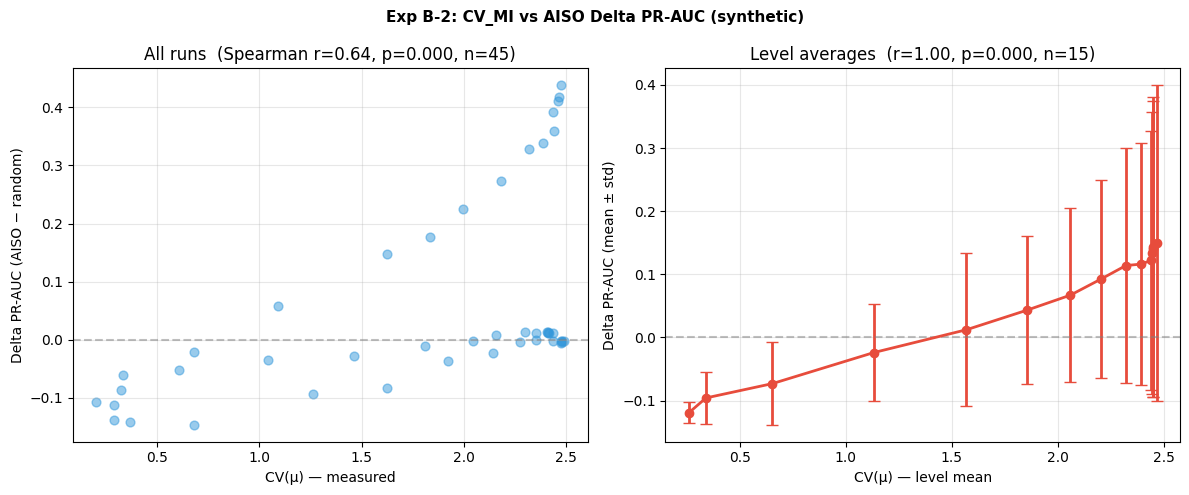


Conclusion: CV_MI significantly predicts AISO outcome (r=0.640, p=0.0000)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: all 45 points
ax = axes[0]
ax.scatter(df_res['cv_mi'], df_res['delta'], alpha=0.5, s=40, color='#3498db')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('CV(μ) — measured')
ax.set_ylabel('Delta PR-AUC (AISO − random)')
ax.set_title(f'All runs  (Spearman r={r:.2f}, p={p:.3f}, n={len(df_res)})')
ax.grid(alpha=0.3)

# Error-bar: level averages
ax = axes[1]
ax.errorbar(df_lvl['cv_mi_mean'], df_lvl['delta_mean'],
            yerr=df_lvl['delta_std'], fmt='o-', capsize=4,
            color='#e74c3c', linewidth=2)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('CV(μ) — level mean')
ax.set_ylabel('Delta PR-AUC (mean ± std)')
ax.set_title(f'Level averages  (r={r2:.2f}, p={p2:.3f}, n={len(df_lvl)})')
ax.grid(alpha=0.3)

plt.suptitle('Exp B-2: CV_MI vs AISO Delta PR-AUC (synthetic)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('exp_b2_synthetic.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nConclusion: CV_MI {"significantly" if p < 0.05 else "does NOT significantly"} predicts AISO outcome (r={r:.3f}, p={p:.4f})')